# Validación Interna TSTR — Conv1D Autoencoder — SWaT A12 (Marzo 2026)

**Objetivo:** entrenar un autoencoder Conv1D bajo tres escenarios y comparar
la calidad de representación de normalidad en datos reales.

| Escenario | Datos de entrenamiento |
|-----------|----------------------|
| `real_only` | Solo ventanas reales normales de A12 |
| `synthetic_only` | Solo ventanas sintéticas del TimeGAN v4 |
| `real_plus_synthetic` | Combinación de ambos |

Val y test siempre son datos reales normales — comparación justa entre escenarios.

## Diferencias respecto al notebook de A7

| Aspecto | A7 2020 | A12 2026 |
|---------|---------|----------|
| Fuente | 4 CSVs sin etiquetas | 1 CSV con `attack_label` |
| Carga | Loop por archivos | DataFrame único, filtrar `label=0` |
| Bad Input | No existe | NaN → moda del train |
| `scaler_cont` / `disc_max` | Calculados aquí | Cargados de 01b |
| `window_size` | 60 | 30 |
| Arquitectura | 2 MaxPool | 1 MaxPool (window=30 no divisible por 4) |
| Features totales | 49 | 62 (31c + 31d) |


## 0. Imports

In [1]:
import json
import random
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

RAW_CSV      = PROJECT_ROOT / "data" / "clean" / "SWaT.A12_OTDataset_Mar_26" / "11-Mar-2026_0900_1700_labeled.csv"
DETECTOR_DIR = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_a12"
TIMEGAN_DIR  = PROJECT_ROOT / "models" / "timegan"   / "conv1d_hybrid_a12_v4"
RESULTS_DIR  = PROJECT_ROOT / "artifacts" / "tstr_internal_validation_a12"
MODELS_DIR   = PROJECT_ROOT / "models"    / "detectors" / "conv1d_tstr_internal_a12"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SYNTH_CONT_PATH  = TIMEGAN_DIR / "synth_for_detector.npy"
SYNTH_DISC_PATH  = TIMEGAN_DIR / "synth_disc_raw.npy"
TIMEGAN_CFG_PATH = TIMEGAN_DIR / "config.json"

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
for p in [RAW_CSV, SYNTH_CONT_PATH, SYNTH_DISC_PATH, TIMEGAN_CFG_PATH,
          DETECTOR_DIR/"scaler_cont.pkl", DETECTOR_DIR/"disc_max_dict.pkl",
          DETECTOR_DIR/"columns_config.json", DETECTOR_DIR/"config.json"]:
    print(f"  {chr(10003) if p.exists() else chr(10007)} {p.name}")


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
  ✓ 11-Mar-2026_0900_1700_labeled.csv
  ✓ synth_for_detector.npy
  ✓ synth_disc_raw.npy
  ✓ config.json
  ✓ scaler_cont.pkl
  ✓ disc_max_dict.pkl
  ✓ columns_config.json
  ✓ config.json


## 2. Cargar configuración

In [4]:
with open(TIMEGAN_CFG_PATH) as f:  tg_cfg  = json.load(f)
with open(DETECTOR_DIR / "columns_config.json") as f: col_cfg = json.load(f)
with open(DETECTOR_DIR / "config.json") as f: det_cfg = json.load(f)

continuous_cols = col_cfg["continuous_cols"]
discrete_cols   = col_cfg["discrete_cols"]
feature_cols    = col_cfg["feature_cols"]

WINDOW_SIZE = int(det_cfg["window_size"])
STRIDE      = int(det_cfg["stride"])
WARMUP      = 120

print(f"window_size: {WINDOW_SIZE} | stride: {STRIDE}")
print(f"continuous_cols: {len(continuous_cols)} | discrete_cols: {len(discrete_cols)}")
print(f"TimeGAN: {tg_cfg.get(chr(118)+chr(101)+chr(114)+chr(115)+chr(105)+chr(111)+chr(110), chr(118)+chr(52))}")


window_size: 30 | stride: 5
continuous_cols: 31 | discrete_cols: 31
TimeGAN: a12_timegan_v4


## 3. Cargar CSV y filtrar filas normales

In [5]:
META_COLS = ["attack_label","attack_id","attack_name","attack_targets","attack_start_time","attack_end_time"]

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw["t_stamp"]      = pd.to_datetime(df_raw["t_stamp"], errors="coerce")
df_raw["attack_label"] = pd.to_numeric(df_raw["attack_label"], errors="coerce").fillna(0).astype(int)
df_raw = df_raw.sort_values("t_stamp").reset_index(drop=True)

# Convertir Bad Input a NaN en columnas de features
df_work = df_raw[["t_stamp", "attack_label"] + feature_cols].copy()
for col in feature_cols:
    df_work[col] = pd.to_numeric(df_work[col].replace("Bad Input", np.nan), errors="coerce")

# Solo filas normales + warmup
df_normal = df_work[df_work["attack_label"] == 0][["t_stamp"] + feature_cols].copy()
df_normal = df_normal[df_normal["t_stamp"] >= df_normal["t_stamp"].min() + pd.Timedelta(seconds=WARMUP)]
df_normal = df_normal.reset_index(drop=True)

n = len(df_normal)
df_train = df_normal.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_normal.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_normal.iloc[int(n*0.80):].copy().reset_index(drop=True)

# Imputar NaN con moda del train
modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

print(f"Filas normales: {len(df_normal)} | Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"NaN tras imputacion: {df_train[feature_cols].isna().sum().sum()}")


Filas normales: 25620 | Train: 15372 | Val: 5124 | Test: 5124
NaN tras imputacion: 0


## 4. Escalado — cargar de 01b

In [6]:
scaler_cont  = joblib.load(DETECTOR_DIR / "scaler_cont.pkl")
disc_max_raw = joblib.load(DETECTOR_DIR / "disc_max_dict.pkl")
disc_max     = pd.Series(disc_max_raw).reindex(discrete_cols).replace(0, 1)

def scale_df(df):
    cont = pd.DataFrame(
        scaler_cont.transform(df[continuous_cols]),
        columns=continuous_cols, index=df.index
    )
    disc = df[discrete_cols].copy() / disc_max
    return pd.concat([cont.reset_index(drop=True), disc.reset_index(drop=True)], axis=1)[feature_cols]

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)
print("Escalado aplicado desde 01b.")
print(f"Rango cont train: [{df_train_sc[continuous_cols].values.min():.2f}, {df_train_sc[continuous_cols].values.max():.2f}]")


Escalado aplicado desde 01b.
Rango cont train: [-6.66, 71.58]


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## 5. Ventanas reales

In [7]:
def build_windows(arr, window_size, stride):
    wins = [arr[i:i+window_size] for i in range(0, len(arr)-window_size+1, stride)]
    return np.array(wins, dtype=np.float32) if wins else np.empty((0,window_size,arr.shape[1]))

train_wins = build_windows(df_train_sc[feature_cols].values, WINDOW_SIZE, STRIDE)
val_wins   = build_windows(df_val_sc[feature_cols].values,   WINDOW_SIZE, STRIDE)
test_wins  = build_windows(df_test_sc[feature_cols].values,  WINDOW_SIZE, STRIDE)

X_train_real = np.transpose(train_wins, (0,2,1)).astype(np.float32)
X_val_real   = np.transpose(val_wins,   (0,2,1)).astype(np.float32)
X_test_real  = np.transpose(test_wins,  (0,2,1)).astype(np.float32)

print(f"X_train_real: {X_train_real.shape}  (N, features, timesteps)")
print(f"X_val_real:   {X_val_real.shape}")
print(f"X_test_real:  {X_test_real.shape}")
print(f"input_channels = {X_train_real.shape[1]}  (31 cont + 31 disc)")


X_train_real: (3069, 62, 30)  (N, features, timesteps)
X_val_real:   (1019, 62, 30)
X_test_real:  (1019, 62, 30)
input_channels = 62  (31 cont + 31 disc)


## 6. Datos sintéticos del TimeGAN v4

In [8]:
synth_cont_raw = np.load(SYNTH_CONT_PATH).astype(np.float32)  # (N,30,31) ya escalado
synth_disc_raw = np.load(SYNTH_DISC_PATH).astype(np.float32)  # (N,30,31) sin escalar

print(f"synth_cont_raw: {synth_cont_raw.shape}")
print(f"synth_disc_raw: {synth_disc_raw.shape}")

assert synth_cont_raw.shape[1] == WINDOW_SIZE
assert synth_cont_raw.shape[2] == len(continuous_cols)
assert synth_disc_raw.shape[2] == len(discrete_cols)

# Escalar discretas con disc_max
synth_disc_scaled = synth_disc_raw / disc_max.values.reshape(1,1,-1).astype(np.float32)

# Combinar y transponer: (N,30,62) -> (N,62,30)
synth_combined = np.concatenate([synth_cont_raw, synth_disc_scaled], axis=2)
X_train_synth  = np.transpose(synth_combined, (0,2,1)).astype(np.float32)

print(f"X_train_synth: {X_train_synth.shape}")
assert X_train_synth.shape[1:] == X_train_real.shape[1:], "Shape mismatch!"
print("Shapes compatibles")


synth_cont_raw: (5115, 30, 31)
synth_disc_raw: (5115, 30, 31)
X_train_synth: (5115, 62, 30)
Shapes compatibles


In [9]:
MATCH_SYNTH_TO_REAL = True

if MATCH_SYNTH_TO_REAL and len(X_train_synth) > len(X_train_real):
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X_train_synth), size=len(X_train_real), replace=False)
    X_train_synth_used = X_train_synth[idx]
    print(f"Sinteticos submuestreados: {len(X_train_synth)} -> {len(X_train_synth_used)}")
else:
    X_train_synth_used = X_train_synth

X_train_mixed = np.concatenate([X_train_real, X_train_synth_used], axis=0).astype(np.float32)

print(f"X_train_real:        {X_train_real.shape}")
print(f"X_train_synth_used:  {X_train_synth_used.shape}")
print(f"X_train_mixed:       {X_train_mixed.shape}  (real + sinteticos)")


Sinteticos submuestreados: 5115 -> 3069
X_train_real:        (3069, 62, 30)
X_train_synth_used:  (3069, 62, 30)
X_train_mixed:       (6138, 62, 30)  (real + sinteticos)


## 7. Arquitectura Conv1D Autoencoder

Con `window_size=30` se usa **1 MaxPool** para garantizar reconstrucción exacta:
- 2 MaxPool: 30→15→7 (encode) / 7→14→28 (decode) ❌ mismatch
- 1 MaxPool: 30→15 (encode) / 15→30 (decode) ✅


In [10]:
class Conv1dAutoencoder(nn.Module):
    def __init__(self, input_channels, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),                               # 30->15
            nn.Conv1d(32, 16, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 32, kernel_size=2, stride=2), nn.ReLU(),  # 15->30
            nn.Conv1d(32, input_channels, kernel_size=3, padding=1),
        )
    def forward(self, x):
        out = self.decoder(self.encoder(x))
        return out[:, :, :self.seq_len]

# Verificar shapes
_m = Conv1dAutoencoder(62, 30)
_x = torch.zeros(4, 62, 30)
_o = _m(_x)
assert _o.shape == _x.shape, f"Mismatch: {_o.shape}"
print(f"Input: {_x.shape} -> Output: {_o.shape} OK")
del _m, _x, _o


Input: torch.Size([4, 62, 30]) -> Output: torch.Size([4, 62, 30]) OK


## 8. Entrenamiento de los 3 escenarios

In [11]:
def make_loader(X, batch_size=64, shuffle=True):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32)),
        batch_size=batch_size, shuffle=shuffle,
        generator=g if shuffle else None
    )


def train_autoencoder(X_train, X_val, scenario_name, epochs, batch_size, lr):
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    model     = Conv1dAutoencoder(X_train.shape[1], WINDOW_SIZE).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    train_loader = make_loader(X_train, batch_size, shuffle=True)
    val_loader   = make_loader(X_val,   batch_size, shuffle=False)

    train_hist, val_hist = [], []
    best_val, best_wts, wait = float('inf'), None, 0
    EARLY_STOP = 15

    print(f'\n=== {scenario_name} ===')
    print(f'Train: {X_train.shape} | Val(real): {X_val.shape}')

    for epoch in range(1, epochs+1):
        model.train()
        tl = 0.0
        for (b,) in train_loader:
            b = b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(b), b)
            loss.backward(); optimizer.step()
            tl += loss.item()
        tl /= len(train_loader)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for (b,) in val_loader:
                vl += criterion(model(b.to(device)), b.to(device)).item()
        vl /= len(val_loader)

        scheduler.step(vl)
        train_hist.append(tl); val_hist.append(vl)

        if vl < best_val - 1e-6:
            best_val = vl
            best_wts = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0:
            print(f'  Ep {epoch:3d}/{epochs} | Train: {tl:.5f} | Val: {vl:.5f} | Best: {best_val:.5f}')

        if wait >= EARLY_STOP:
            print(f'  Early stopping en epoch {epoch}')
            break

    model.load_state_dict(best_wts)
    model.eval()
    return model, train_hist, val_hist


def reconstruction_errors(model, X, batch_size=256):
    loader = make_loader(X, batch_size, shuffle=False)
    errors = []
    model.eval()
    with torch.no_grad():
        for (b,) in loader:
            b = b.to(device)
            err = torch.mean((model(b) - b)**2, dim=(1,2))
            errors.extend(err.cpu().numpy())
    return np.array(errors)


def error_summary(errors, prefix):
    return {
        f'{prefix}_mean':   float(np.mean(errors)),
        f'{prefix}_std':    float(np.std(errors)),
        f'{prefix}_median': float(np.median(errors)),
        f'{prefix}_p90':    float(np.percentile(errors, 90)),
        f'{prefix}_p95':    float(np.percentile(errors, 95)),
        f'{prefix}_p99':    float(np.percentile(errors, 99)),
    }


def compute_far_table(val_errors, test_errors, percentiles=(90, 95, 97.5, 99, 99.5)):
    rows = []
    for p in percentiles:
        tau = np.percentile(val_errors, p)
        rows.append({'percentile': p, 'tau': float(tau),
                     'FAR_val':  float(np.mean(val_errors > tau)),
                     'FAR_test': float(np.mean(test_errors > tau))})
    return pd.DataFrame(rows)


In [12]:
EPOCHS     = 60
BATCH_SIZE = 64
LR         = 1e-3

SCENARIOS = {
    'real_only':           X_train_real,
    'synthetic_only':      X_train_synth_used,
    'real_plus_synthetic': X_train_mixed,
}

models, histories, all_errors, far_tables, summary_rows = {}, {}, {}, {}, []

for scenario_name, X_train_sc in SCENARIOS.items():
    model, train_hist, val_hist = train_autoencoder(
        X_train_sc, X_val_real, scenario_name, EPOCHS, BATCH_SIZE, LR)
    train_err = reconstruction_errors(model, X_train_sc)
    val_err   = reconstruction_errors(model, X_val_real)
    test_err  = reconstruction_errors(model, X_test_real)
    models[scenario_name]     = model
    histories[scenario_name]  = {'train_loss': train_hist, 'val_loss': val_hist}
    all_errors[scenario_name] = {'train': train_err, 'val': val_err, 'test': test_err}
    far_tables[scenario_name] = compute_far_table(val_err, test_err)
    row = {'scenario': scenario_name}
    row.update(error_summary(train_err, 'train_error'))
    row.update(error_summary(val_err,   'val_error'))
    row.update(error_summary(test_err,  'test_error'))
    row['final_train_loss'] = train_hist[-1]
    row['final_val_loss']   = val_hist[-1]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print('\n=== Tabla resumen ===')
display(summary_df[['scenario','final_train_loss','final_val_loss',
                     'val_error_mean','val_error_std','val_error_p95','val_error_p99']])



=== real_only ===
Train: (3069, 62, 30) | Val(real): (1019, 62, 30)
  Ep  10/60 | Train: 0.04616 | Val: 0.59202 | Best: 0.59202
  Ep  20/60 | Train: 0.01915 | Val: 0.21161 | Best: 0.20649
  Ep  30/60 | Train: 0.01163 | Val: 0.17330 | Best: 0.17330
  Ep  40/60 | Train: 0.00910 | Val: 0.16760 | Best: 0.15653
  Ep  50/60 | Train: 0.00777 | Val: 0.15761 | Best: 0.15653
  Early stopping en epoch 50

=== synthetic_only ===
Train: (3069, 62, 30) | Val(real): (1019, 62, 30)
  Ep  10/60 | Train: 0.04858 | Val: 1.89968 | Best: 1.89968
  Ep  20/60 | Train: 0.03734 | Val: 1.88554 | Best: 1.88413
  Ep  30/60 | Train: 0.02945 | Val: 1.88889 | Best: 1.88338
  Early stopping en epoch 36

=== real_plus_synthetic ===
Train: (6138, 62, 30) | Val(real): (1019, 62, 30)
  Ep  10/60 | Train: 0.03750 | Val: 0.27876 | Best: 0.27876
  Ep  20/60 | Train: 0.02459 | Val: 0.23980 | Best: 0.22289
  Ep  30/60 | Train: 0.02071 | Val: 0.18862 | Best: 0.18862
  Ep  40/60 | Train: 0.01871 | Val: 0.18451 | Best: 0.17848


,scenario,final_train_loss,final_val_loss,val_error_mean,val_error_std,val_error_p95,val_error_p99
0,real_only,0.007767,0.157609,0.156836,0.401263,1.566848,1.687953
1,synthetic_only,0.028705,1.889237,1.890759,6.302238,26.291224,27.073425
2,real_plus_synthetic,0.017121,0.177460,0.172655,0.400124,1.457404,1.703287


## 9. Visualizaciones

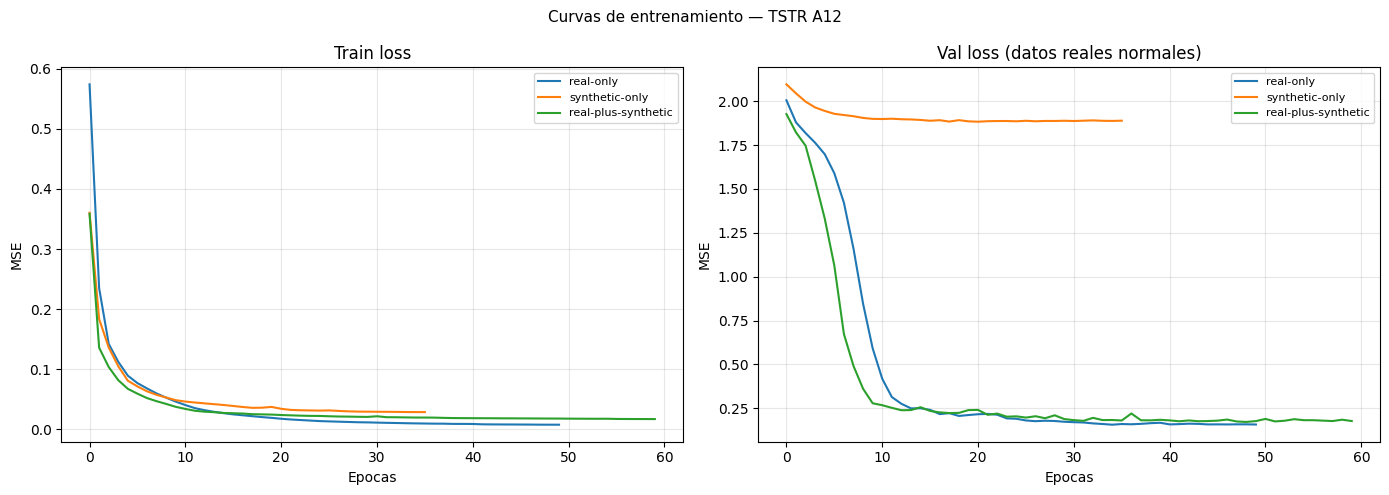

In [13]:
COLORS = {'real_only':'#1f77b4','synthetic_only':'#ff7f0e','real_plus_synthetic':'#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sc, hist in histories.items():
    axes[0].plot(hist['train_loss'], color=COLORS[sc], label=sc.replace('_','-'), lw=1.5)
    axes[1].plot(hist['val_loss'],   color=COLORS[sc], label=sc.replace('_','-'), lw=1.5)
for ax, t in zip(axes, ['Train loss', 'Val loss (datos reales normales)']):
    ax.set_title(t); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlabel('Epocas'); ax.set_ylabel('MSE')
plt.suptitle('Curvas de entrenamiento — TSTR A12', fontsize=11)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


C:\Users\Juan\AppData\Local\Temp\ipykernel_4956\3012137193.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([all_errors[sc]['val'] for sc in SCENARIOS],


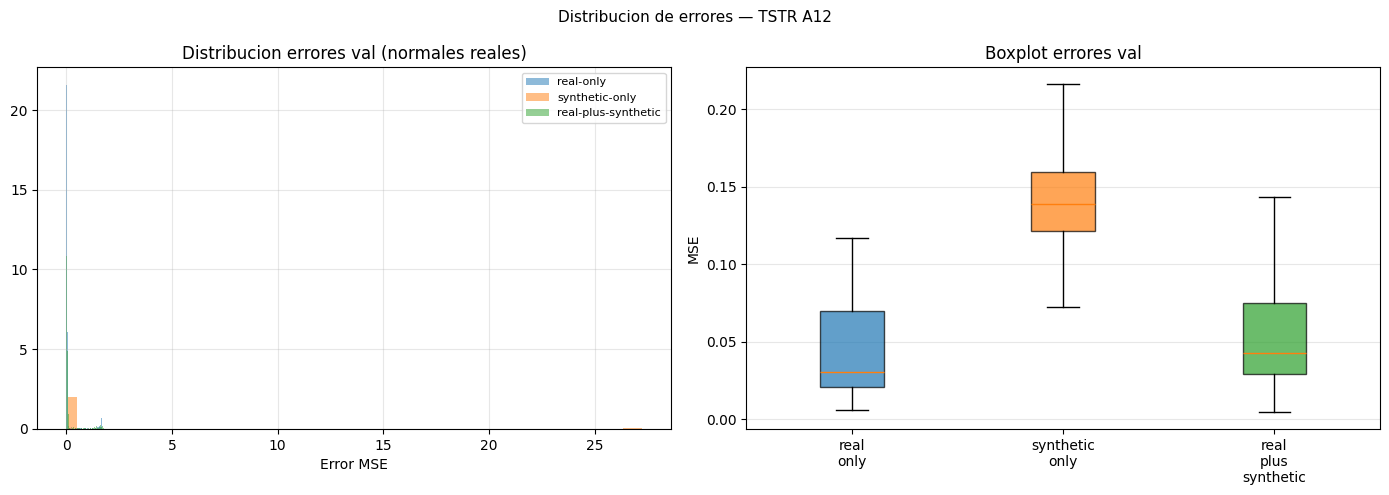

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sc in SCENARIOS:
    axes[0].hist(all_errors[sc]['val'], bins=60, alpha=0.5, density=True,
                 color=COLORS[sc], label=sc.replace('_','-'))
axes[0].set_title('Distribucion errores val (normales reales)')
axes[0].set_xlabel('Error MSE'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

bp = axes[1].boxplot([all_errors[sc]['val'] for sc in SCENARIOS],
                     labels=[s.replace('_','\n') for s in SCENARIOS],
                     patch_artist=True, showfliers=False)
for patch, sc in zip(bp['boxes'], SCENARIOS):
    patch.set_facecolor(COLORS[sc]); patch.set_alpha(0.7)
axes[1].set_title('Boxplot errores val'); axes[1].set_ylabel('MSE'); axes[1].grid(True, axis='y', alpha=0.3)
plt.suptitle('Distribucion de errores — TSTR A12', fontsize=11)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'error_distributions.png'), dpi=120, bbox_inches='tight')
plt.show()


In [15]:
# FAR table y umbrales
tau_rows = []
for sc in SCENARIOS:
    for p in [90, 95, 97.5, 99, 99.5]:
        key = f'p{str(p).replace(".","_")}'
        tau_rows.append({'scenario': sc, 'percentil': p,
                         'tau': float(np.percentile(all_errors[sc]['val'], p))})

tau_df = pd.DataFrame(tau_rows)
pivot  = tau_df.pivot(index='percentil', columns='scenario', values='tau')[list(SCENARIOS.keys())]
print('Umbrales tau por escenario:')
display(pivot)

print('\nFAR tabla — real_only:')
display(far_tables['real_only'])


Umbrales tau por escenario:


scenario,real_only,synthetic_only,real_plus_synthetic
percentil,,,
90.0,0.112065,0.308062,0.151883
95.0,1.566848,26.291224,1.457404
97.5,1.665655,26.807714,1.640038
99.0,1.687953,27.073425,1.703287
99.5,1.690998,27.182907,1.737284



FAR tabla — real_only:


,percentile,tau,FAR_val,FAR_test
0,90.0,0.112065,0.100098,0.316977
1,95.0,1.566848,0.050049,0.019627
2,97.5,1.665655,0.025515,0.019627
3,99.0,1.687953,0.010795,0.019627
4,99.5,1.690998,0.005888,0.019627


## 10. Guardar artefactos

In [16]:
# Artefactos globales
summary_df.to_csv(RESULTS_DIR / 'summary_errors.csv', index=False)
joblib.dump(scaler_cont, RESULTS_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max,    RESULTS_DIR / 'disc_max.pkl')

with open(RESULTS_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols': continuous_cols, 'discrete_cols': discrete_cols,
               'feature_cols': feature_cols}, f, indent=4)

with open(RESULTS_DIR / 'config.json', 'w') as f:
    json.dump({'scenarios':    list(SCENARIOS.keys()),
               'window_size':  WINDOW_SIZE, 'stride': STRIDE,
               'epochs':       EPOCHS, 'batch_size': BATCH_SIZE, 'lr': LR,
               'dataset':      'SWaT A12 Mar 2026',
               'n_train_real': int(len(X_train_real)),
               'n_synth_used': int(len(X_train_synth_used)),
               'n_val':        int(len(X_val_real)),
               'n_test':       int(len(X_test_real)),
               'input_channels': int(X_train_real.shape[1])}, f, indent=4)

# Por escenario
for scenario in SCENARIOS:
    sc_dir = MODELS_DIR / scenario
    sc_dir.mkdir(parents=True, exist_ok=True)

    torch.save(models[scenario].state_dict(), sc_dir / 'model_state.pt')
    pd.DataFrame(histories[scenario]).to_csv(sc_dir / 'train_history.csv', index=False)
    np.save(sc_dir / 'train_errors.npy', all_errors[scenario]['train'])
    np.save(sc_dir / 'val_errors.npy',   all_errors[scenario]['val'])
    np.save(sc_dir / 'test_errors.npy',  all_errors[scenario]['test'])
    far_tables[scenario].to_csv(sc_dir / 'far_table.csv', index=False)

    tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(all_errors[scenario]['val'], p))
                for p in [90, 95, 97.5, 99, 99.5]}
    with open(sc_dir / 'tau_dict.json', 'w') as f:
        json.dump(tau_dict, f, indent=4)

    with open(sc_dir / 'config.json', 'w') as f:
        json.dump({'scenario': scenario,
                   'model_class': 'Conv1dAutoencoder',
                   'input_channels': int(X_train_real.shape[1]),
                   'seq_len': WINDOW_SIZE, 'window_size': WINDOW_SIZE, 'stride': STRIDE,
                   'epochs_run': len(histories[scenario]['train_loss']),
                   'final_val_loss': float(histories[scenario]['val_loss'][-1]),
                   'val_error_mean': float(np.mean(all_errors[scenario]['val'])),
                   'val_error_p95':  float(np.percentile(all_errors[scenario]['val'], 95)),
                   'val_error_p99':  float(np.percentile(all_errors[scenario]['val'], 99)),
                   'tau_dict': tau_dict,
                   'continuous_cols': continuous_cols, 'discrete_cols': discrete_cols,
                   'feature_cols': feature_cols,
                   'train_shape': list(SCENARIOS[scenario].shape),
                   'val_shape': list(X_val_real.shape),
                   'test_shape': list(X_test_real.shape)}, f, indent=4)

print('Artefactos guardados.')
print('RESULTS_DIR:', RESULTS_DIR.resolve())
for fp in sorted(RESULTS_DIR.iterdir()): print(f'  {fp.name}')
print('MODELS_DIR:', MODELS_DIR.resolve())
for sc_d in sorted(MODELS_DIR.iterdir()):
    print(f'  {sc_d.name}/  -> {[f.name for f in sorted(sc_d.iterdir())]}')


Artefactos guardados.
RESULTS_DIR: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_internal_validation_a12
  columns_config.json
  config.json
  disc_max.pkl
  error_distributions.png
  scaler_cont.pkl
  summary_errors.csv
  training_curves.png
MODELS_DIR: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_tstr_internal_a12
  real_only/  -> ['config.json', 'far_table.csv', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_errors.npy', 'train_history.csv', 'val_errors.npy']
  real_plus_synthetic/  -> ['config.json', 'far_table.csv', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_errors.npy', 'train_history.csv', 'val_errors.npy']
  synthetic_only/  -> ['config.json', 'far_table.csv', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_errors.npy', 'train_history.csv', 'val_errors.npy']


## 11. Interpretación

### Cómo leer la tabla

- **val_error_mean menor** en `real_plus_synthetic` vs `real_only`: los sintéticos mejoraron la representación de normalidad.
- **val_error_std menor**: distribución de errores más compacta → umbrales de detección más precisos.
- **synthetic_only con error alto**: esperado — el modelo no vio distribución real.

### Próximo paso

Los modelos en `conv1d_tstr_internal_a12/` se usarán en la validación externa supervisada
con el dataset A12 etiquetado para calcular F1, Recall y ROC-AUC bajo los tres escenarios.
